In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 614
Number of columns: 13


In [6]:
df.head()


,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,lp001002,male,no,0,graduate,no,5849,0.0,NaN,360.0,1.0,urban,y
1,lp001003,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural,n
2,lp001005,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban,y
3,lp001006,male,yes,0,not graduate,no,2583,2358.0,120.0,360.0,1.0,urban,y
4,lp001008,male,no,0,graduate,no,6000,0.0,141.0,360.0,1.0,urban,y


In [7]:
print("Columns in the dataset:")
for column in df.columns:
    print("-", column)

Columns in the dataset:
- loan_id
- gender
- married
- dependents
- education
- self_employed
- applicantincome
- coapplicantincome
- loanamount
- loan_amount_term
- credit_history
- property_area
- loan_status


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            614 non-null    str    
 1   gender             601 non-null    str    
 2   married            611 non-null    str    
 3   dependents         599 non-null    str    
 4   education          614 non-null    str    
 5   self_employed      582 non-null    str    
 6   applicantincome    614 non-null    int64  
 7   coapplicantincome  614 non-null    float64
 8   loanamount         592 non-null    float64
 9   loan_amount_term   600 non-null    float64
 10  credit_history     564 non-null    float64
 11  property_area      614 non-null    str    
 12  loan_status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [9]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
loan_id               0
gender               13
married               3
dependents           15
education             0
self_employed        32
applicantincome       0
coapplicantincome     0
loanamount           22
loan_amount_term     14
credit_history       50
property_area         0
loan_status           0
dtype: int64


In [10]:
print("\nPercentage of missing values:")
print((df.isnull().sum() / len(df) * 100).round(2))


Percentage of missing values:
loan_id              0.00
gender               2.12
married              0.49
dependents           2.44
education            0.00
self_employed        5.21
applicantincome      0.00
coapplicantincome    0.00
loanamount           3.58
loan_amount_term     2.28
credit_history       8.14
property_area        0.00
loan_status          0.00
dtype: float64


In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [12]:
print(df["loan_status"].value_counts())

loan_status
y    422
n    192
Name: count, dtype: int64


In [13]:
print(df["loan_status"].value_counts(normalize=True) * 100)

loan_status
y    68.729642
n    31.270358
Name: proportion, dtype: float64


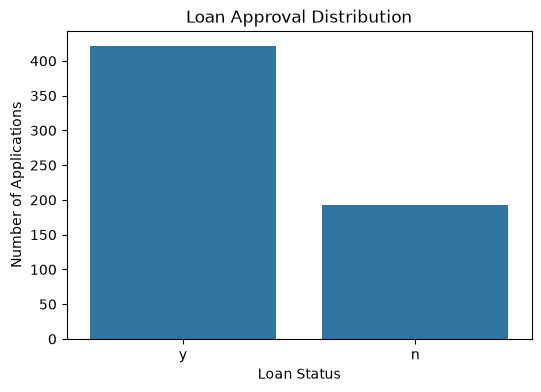

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="loan_status")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

In [15]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['applicantincome', 'coapplicantincome', 'loanamount', 'loan_amount_term', 'credit_history']


In [16]:
df[numerical_columns].describe()

,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [17]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['loan_id', 'gender', 'married', 'dependents', 'education', 'self_employed', 'property_area', 'loan_status']


C:\Users\RUPES\AppData\Local\Temp\ipykernel_3876\2798951942.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [18]:
for column in categorical_columns:
    print("\n" + "=" * 40)
    print(column)
    print("=" * 40)
    print(df[column].value_counts(dropna=False))


loan_id
loan_id
lp001002    1
lp001003    1
lp001005    1
lp001006    1
lp001008    1
           ..
lp002978    1
lp002979    1
lp002983    1
lp002984    1
lp002990    1
Name: count, Length: 614, dtype: int64

gender
gender
male      489
female    112
NaN        13
Name: count, dtype: int64

married
married
yes    398
no     213
NaN      3
Name: count, dtype: int64

dependents
dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64

education
education
graduate        480
not graduate    134
Name: count, dtype: int64

self_employed
self_employed
no     500
yes     82
NaN     32
Name: count, dtype: int64

property_area
property_area
semiurban    233
urban        202
rural        179
Name: count, dtype: int64

loan_status
loan_status
y    422
n    192
Name: count, dtype: int64


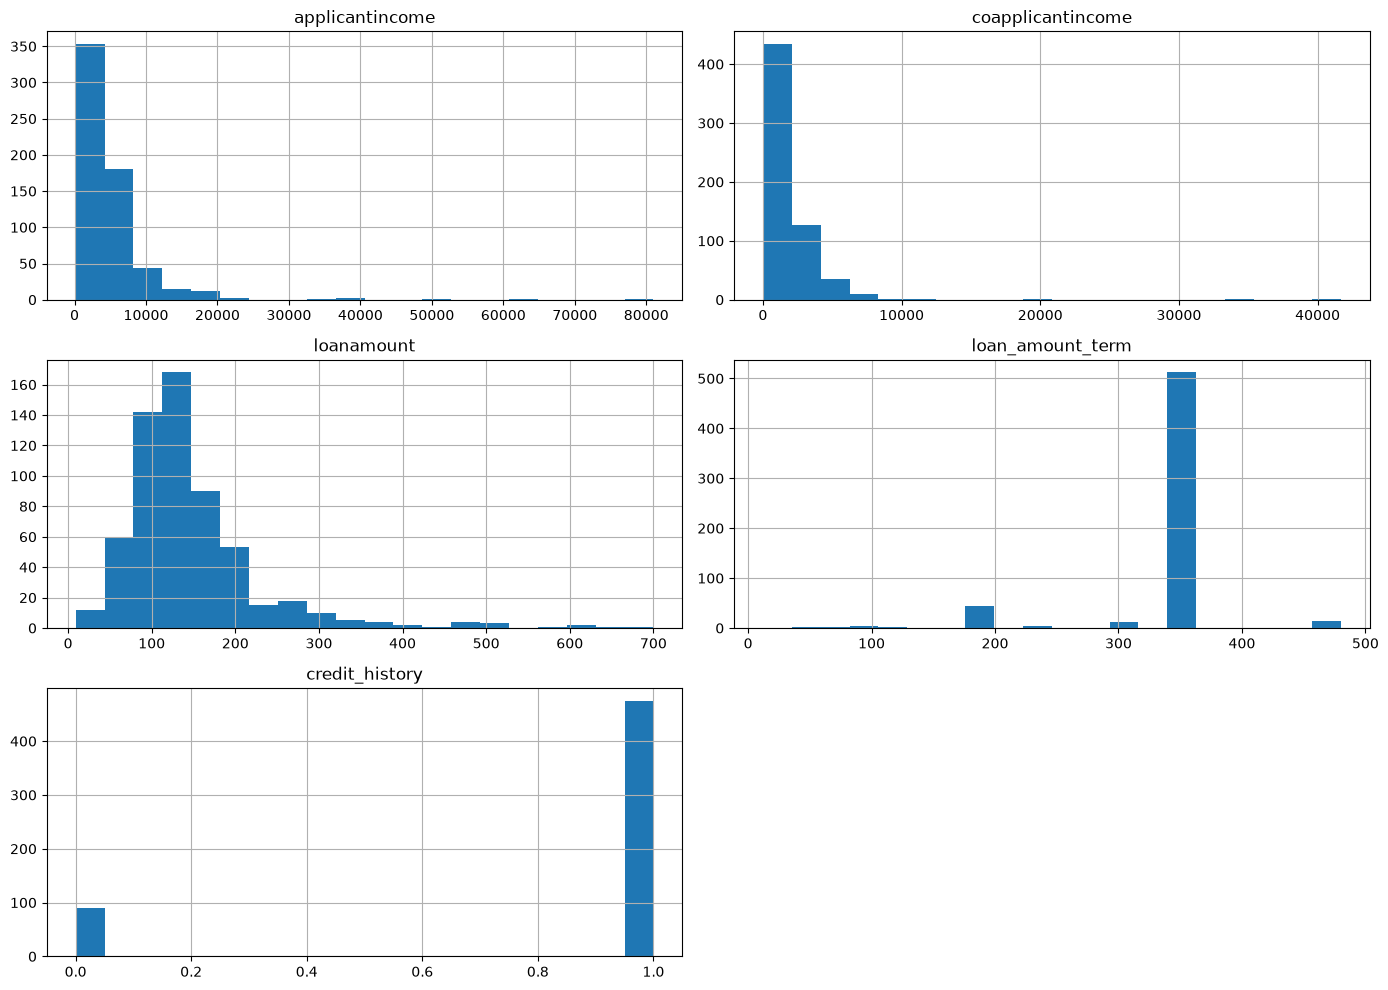

In [19]:
df[numerical_columns].hist(
    figsize=(14, 10),
    bins=20
)

plt.tight_layout()
plt.show()

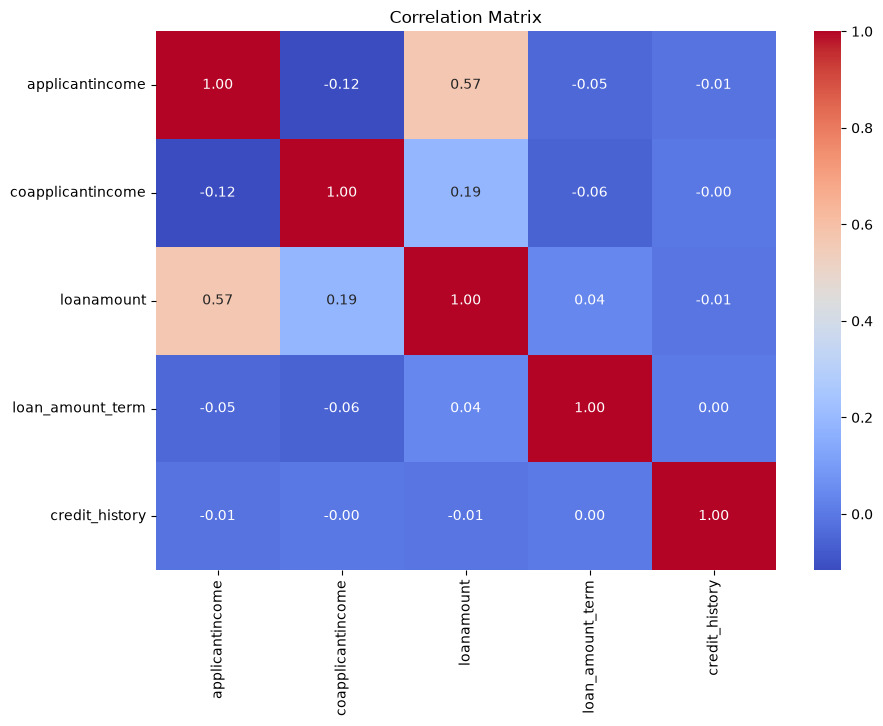

In [20]:
plt.figure(figsize=(10, 7))

correlation = df[numerical_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [21]:
credit_status = pd.crosstab(
    df["credit_history"],
    df["loan_status"],
    normalize="index"
) * 100

print(credit_status)

loan_status             n          y
credit_history                      
0.0             92.134831   7.865169
1.0             20.421053  79.578947


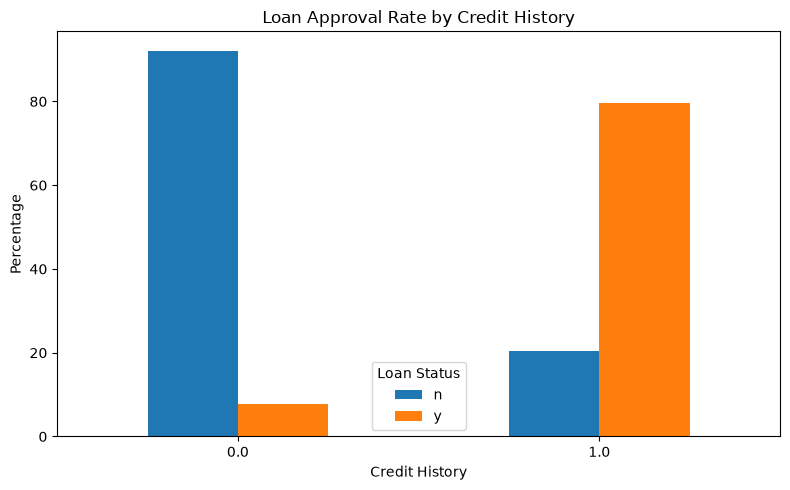

In [22]:
credit_status.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Loan Approval Rate by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")

plt.tight_layout()
plt.show()

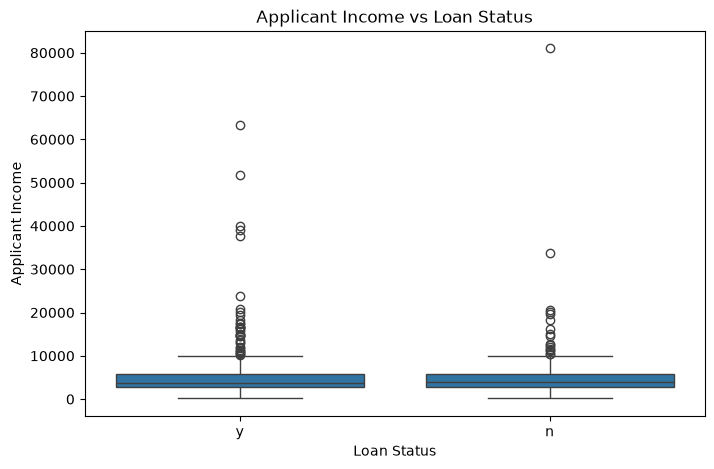

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="applicantincome"
)

plt.title("Applicant Income vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")

plt.show()

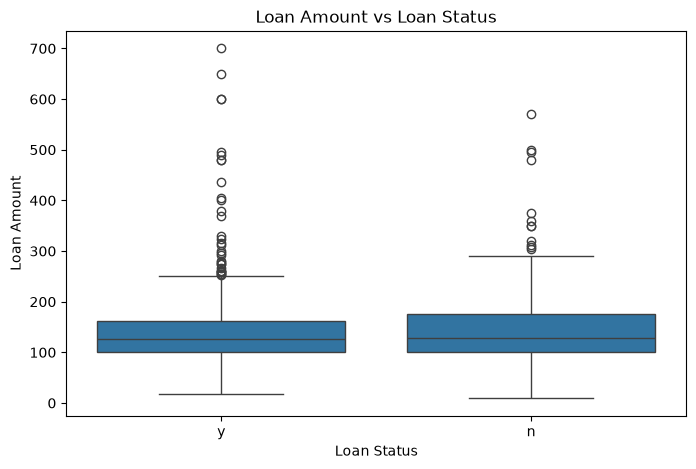

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="loanamount"
)

plt.title("Loan Amount vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")

plt.show()

In [25]:
property_status = pd.crosstab(
    df["property_area"],
    df["loan_status"],
    normalize="index"
) * 100

print(property_status)

loan_status            n          y
property_area                      
rural          38.547486  61.452514
semiurban      23.175966  76.824034
urban          34.158416  65.841584


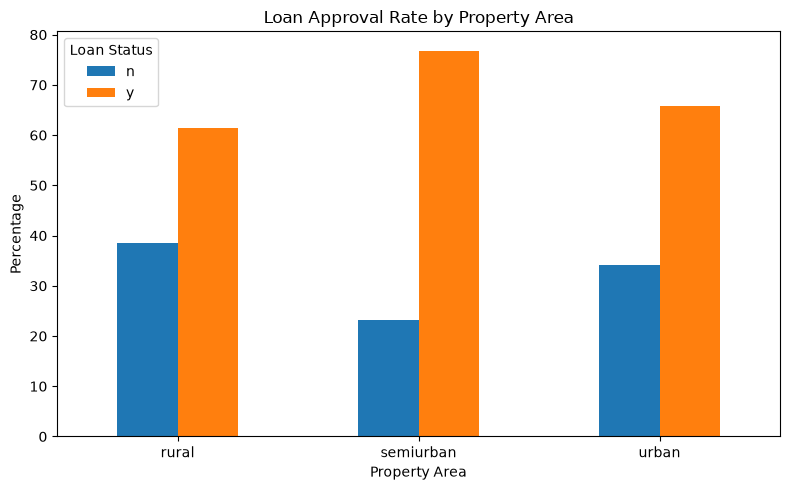

In [26]:
property_status.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Loan Approval Rate by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")

plt.tight_layout()
plt.show()

In [27]:
education_status = pd.crosstab(
    df["education"],
    df["loan_status"],
    normalize="index"
) * 100

print(education_status)

loan_status           n          y
education                         
graduate      29.166667  70.833333
not graduate  38.805970  61.194030


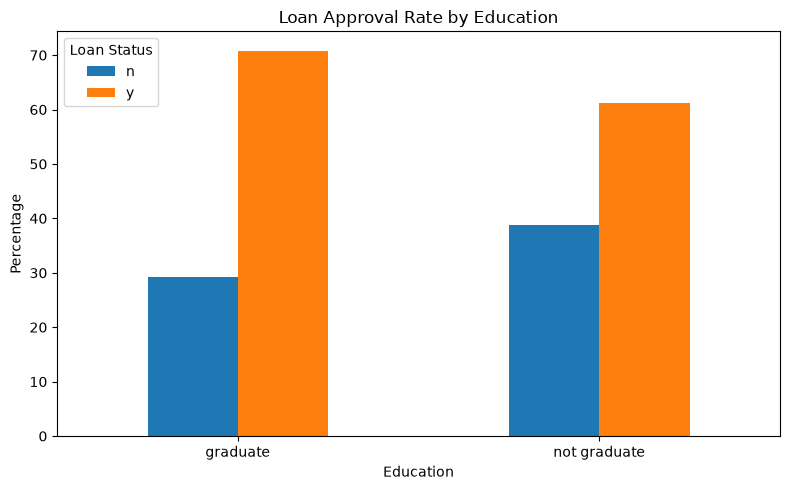

In [28]:
education_status.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Loan Approval Rate by Education")
plt.xlabel("Education")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")

plt.tight_layout()
plt.show()

In [29]:
df_clean = df.copy()

print("Working copy created.")
print("Shape:", df_clean.shape)

Working copy created.
Shape: (614, 13)


In [30]:
df_clean = df_clean.drop(columns=["loan_id"])

print("loan_id removed.")
print("Remaining columns:")
print(df_clean.columns.tolist())

loan_id removed.
Remaining columns:
['gender', 'married', 'dependents', 'education', 'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount', 'loan_amount_term', 'credit_history', 'property_area', 'loan_status']


In [31]:
df_clean["dependents"] = df_clean["dependents"].replace("3+", "3")

df_clean["dependents"] = pd.to_numeric(
    df_clean["dependents"],
    errors="coerce"
)

print(df_clean["dependents"].value_counts(dropna=False).sort_index())

dependents
0.0    345
1.0    102
2.0    101
3.0     51
NaN     15
Name: count, dtype: int64


In [32]:
df_clean["loan_status"] = df_clean["loan_status"].map({
    "y": 1,
    "n": 0
})

print(df_clean["loan_status"].value_counts())

loan_status
1    422
0    192
Name: count, dtype: int64


In [33]:
missing = df_clean.isnull().sum()

print("Missing values after initial cleaning:")
print(missing[missing > 0])

Missing values after initial cleaning:
gender              13
married              3
dependents          15
self_employed       32
loanamount          22
loan_amount_term    14
credit_history      50
dtype: int64


In [34]:
features = [
    "married",
    "dependents",
    "education",
    "self_employed",
    "applicantincome",
    "coapplicantincome",
    "loanamount",
    "loan_amount_term",
    "credit_history",
    "property_area"
]

target = "loan_status"

In [35]:
X = df_clean[features]
y = df_clean[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (614, 10)
Target shape: (614,)


In [36]:
numerical_features = [
    "dependents",
    "applicantincome",
    "coapplicantincome",
    "loanamount",
    "loan_amount_term",
    "credit_history"
]

categorical_features = [
    "married",
    "education",
    "self_employed",
    "property_area"
]

In [37]:
print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['dependents', 'applicantincome', 'coapplicantincome', 'loanamount', 'loan_amount_term', 'credit_history']

Categorical features:
['married', 'education', 'self_employed', 'property_area']


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 491
Testing samples: 123


In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [40]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [42]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (491, 15)
Processed testing shape: (123, 15)


In [43]:
preprocessor.fit_transform(X_train)

array([[-0.74858624, -0.352802  , -0.56322811, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.25020681, -0.3433464 , -0.56322811, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.24899986, -0.33947116,  0.05040502, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.74858624, -0.42333146,  0.24526045, ...,  0.        ,
         1.        ,  0.        ],
       [-0.74858624, -0.47215955,  0.26284409, ...,  0.        ,
         1.        ,  0.        ],
       [-0.74858624, -0.48161515, -0.38200897, ...,  0.        ,
         1.        ,  0.        ]], shape=(491, 15))

In [44]:
preprocessor.transform(X_test)

array([[-0.74858624,  0.11579264, -0.56322811, ...,  1.        ,
         0.        ,  0.        ],
       [-0.74858624, -0.20926292,  0.26427949, ...,  0.        ,
         1.        ,  0.        ],
       [-0.74858624,  0.68715878, -0.56322811, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 2.24779292, -0.38659414,  0.33533175, ...,  0.        ,
         1.        ,  0.        ],
       [-0.74858624,  0.61662932, -0.56322811, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.25020681, -0.38256388,  0.14980641, ...,  0.        ,
         0.        ,  1.        ]], shape=(123, 15))

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [47]:
logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [48]:
y_pred_logistic = logistic_model.predict(X_test_processed)

print("Predictions generated successfully!")
print(y_pred_logistic[:20])

Predictions generated successfully!
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1]


In [49]:
y_probability_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

print(y_probability_logistic[:10])

[0.05831363 0.86839146 0.73898408 0.78798116 0.86045574 0.82368308
 0.88746368 0.85710798 0.71057303 0.74397849]


In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [51]:
accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8618


In [52]:
precision = precision_score(
    y_test,
    y_pred_logistic
)

print(f"Precision: {precision:.4f}")

Precision: 0.8400


In [53]:
recall = recall_score(
    y_test,
    y_pred_logistic
)

print(f"Recall: {recall:.4f}")

Recall: 0.9882


In [54]:
f1 = f1_score(
    y_test,
    y_pred_logistic
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.9081


In [55]:
roc_auc = roc_auc_score(
    y_test,
    y_probability_logistic
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8554


In [56]:
print("===== Logistic Regression Results =====")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

===== Logistic Regression Results =====
Accuracy : 0.8618
Precision: 0.8400
Recall   : 0.9882
F1 Score : 0.9081
ROC-AUC  : 0.8554


In [57]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Not Approved", "Approved"]
    )
)

              precision    recall  f1-score   support

Not Approved       0.96      0.58      0.72        38
    Approved       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



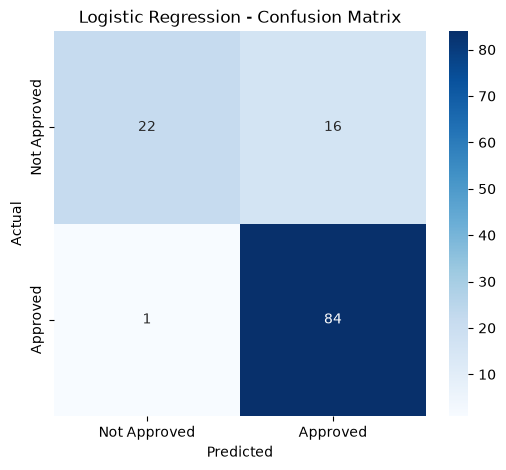

In [58]:
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Approved", "Approved"],
    yticklabels=["Not Approved", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [59]:
from sklearn.tree import DecisionTreeClassifier

In [60]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

In [61]:
decision_tree.fit(
    X_train_processed,
    y_train
)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [62]:
y_pred_tree = decision_tree.predict(X_test_processed)

y_probability_tree = decision_tree.predict_proba(
    X_test_processed
)[:, 1]

In [63]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)
tree_roc_auc = roc_auc_score(y_test, y_probability_tree)

print("===== Decision Tree Results =====")

print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1 Score : {tree_f1:.4f}")
print(f"ROC-AUC  : {tree_roc_auc:.4f}")

===== Decision Tree Results =====
Accuracy : 0.8211
Precision: 0.8247
Recall   : 0.9412
F1 Score : 0.8791
ROC-AUC  : 0.7259


In [64]:
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["Not Approved", "Approved"]
    )
)

              precision    recall  f1-score   support

Not Approved       0.81      0.55      0.66        38
    Approved       0.82      0.94      0.88        85

    accuracy                           0.82       123
   macro avg       0.82      0.75      0.77       123
weighted avg       0.82      0.82      0.81       123



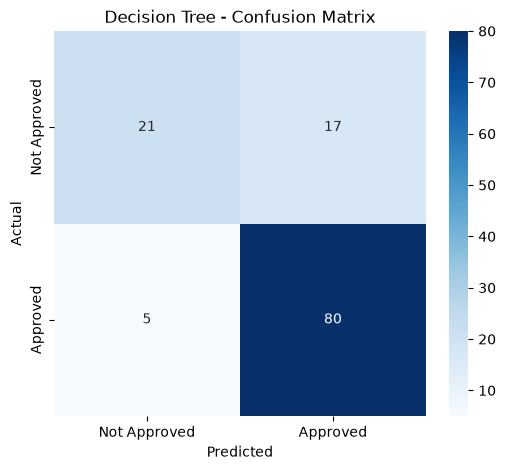

In [65]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Approved", "Approved"],
    yticklabels=["Not Approved", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [66]:
from sklearn.ensemble import RandomForestClassifier

In [67]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

In [68]:
random_forest.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [69]:
y_pred_rf = random_forest.predict(X_test_processed)

y_probability_rf = random_forest.predict_proba(
    X_test_processed
)[:, 1]

In [70]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_probability_rf)

print("===== Random Forest Results =====")

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

===== Random Forest Results =====
Accuracy : 0.7967
Precision: 0.8409
Recall   : 0.8706
F1 Score : 0.8555
ROC-AUC  : 0.8214


In [71]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Not Approved", "Approved"]
    )
)

              precision    recall  f1-score   support

Not Approved       0.69      0.63      0.66        38
    Approved       0.84      0.87      0.86        85

    accuracy                           0.80       123
   macro avg       0.76      0.75      0.76       123
weighted avg       0.79      0.80      0.79       123



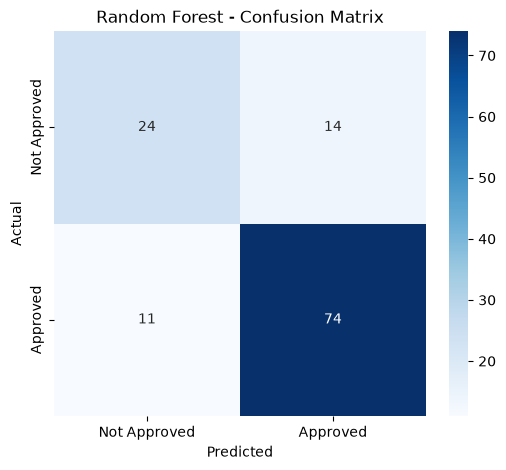

In [72]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Approved", "Approved"],
    yticklabels=["Not Approved", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

In [73]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [74]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [75]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced"
    ))
])

In [76]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [77]:
cv_logistic = cross_validate(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring
)

print("Logistic Regression")
print("Accuracy :", cv_logistic["test_accuracy"].mean())
print("Precision:", cv_logistic["test_precision"].mean())
print("Recall   :", cv_logistic["test_recall"].mean())
print("F1       :", cv_logistic["test_f1"].mean())
print("ROC-AUC  :", cv_logistic["test_roc_auc"].mean())

Logistic Regression
Accuracy : 0.8062241769958683
Precision: 0.7908569475953613
Recall   : 0.9762745098039216
F1       : 0.8737999053841226
ROC-AUC  : 0.7489911430159109


In [78]:
cv_tree = cross_validate(
    tree_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring
)

print("Decision Tree")
print("Accuracy :", cv_tree["test_accuracy"].mean())
print("Precision:", cv_tree["test_precision"].mean())
print("Recall   :", cv_tree["test_recall"].mean())
print("F1       :", cv_tree["test_f1"].mean())
print("ROC-AUC  :", cv_tree["test_roc_auc"].mean())

Decision Tree
Accuracy : 0.7850593096094896
Precision: 0.7780400254106133
Recall   : 0.9620448179271708
F1       : 0.8602129713859983
ROC-AUC  : 0.6824622926093513


In [79]:
cv_rf = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring
)

print("Random Forest")
print("Accuracy :", cv_rf["test_accuracy"].mean())
print("Precision:", cv_rf["test_precision"].mean())
print("Recall   :", cv_rf["test_recall"].mean())
print("F1       :", cv_rf["test_f1"].mean())
print("ROC-AUC  :", cv_rf["test_roc_auc"].mean())

Random Forest
Accuracy : 0.7410502465680395
Precision: 0.7853573258126444
Recall   : 0.8579551820728291
F1       : 0.8193820063143675
ROC-AUC  : 0.7534053459440456


In [80]:
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

print("Final Logistic Regression pipeline trained successfully!")

Final Logistic Regression pipeline trained successfully!


In [81]:
final_predictions = final_model.predict(X_test)

final_probabilities = final_model.predict_proba(X_test)[:, 1]

print("Final model accuracy:",
      accuracy_score(y_test, final_predictions))

print("Final model ROC-AUC:",
      roc_auc_score(y_test, final_probabilities))

Final model accuracy: 0.8617886178861789
Final model ROC-AUC: 0.8554179566563468


In [82]:
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nProcessed features:")
for feature in feature_names:
    print(feature)

Number of processed features: 15

Processed features:
num__dependents
num__applicantincome
num__coapplicantincome
num__loanamount
num__loan_amount_term
num__credit_history
cat__married_no
cat__married_yes
cat__education_graduate
cat__education_not graduate
cat__self_employed_no
cat__self_employed_yes
cat__property_area_rural
cat__property_area_semiurban
cat__property_area_urban


In [83]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [84]:
X_train_transformed = final_model.named_steps[
    "preprocessor"
].transform(X_train)

X_test_transformed = final_model.named_steps[
    "preprocessor"
].transform(X_test)

print("Training data shape:", X_train_transformed.shape)
print("Testing data shape:", X_test_transformed.shape)

Training data shape: (491, 15)
Testing data shape: (123, 15)


In [85]:
model = final_model.named_steps["model"]

explainer = shap.LinearExplainer(
    model,
    X_train_transformed
)

print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [86]:
shap_values = explainer(X_test_transformed)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


In [87]:
print(shap_values.shape)

(123, 15)


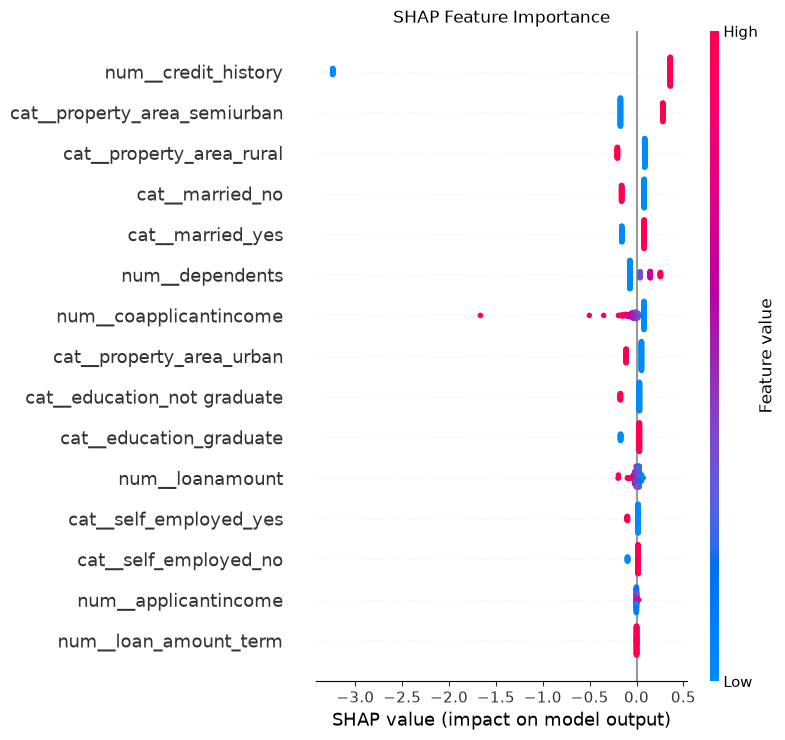

In [88]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

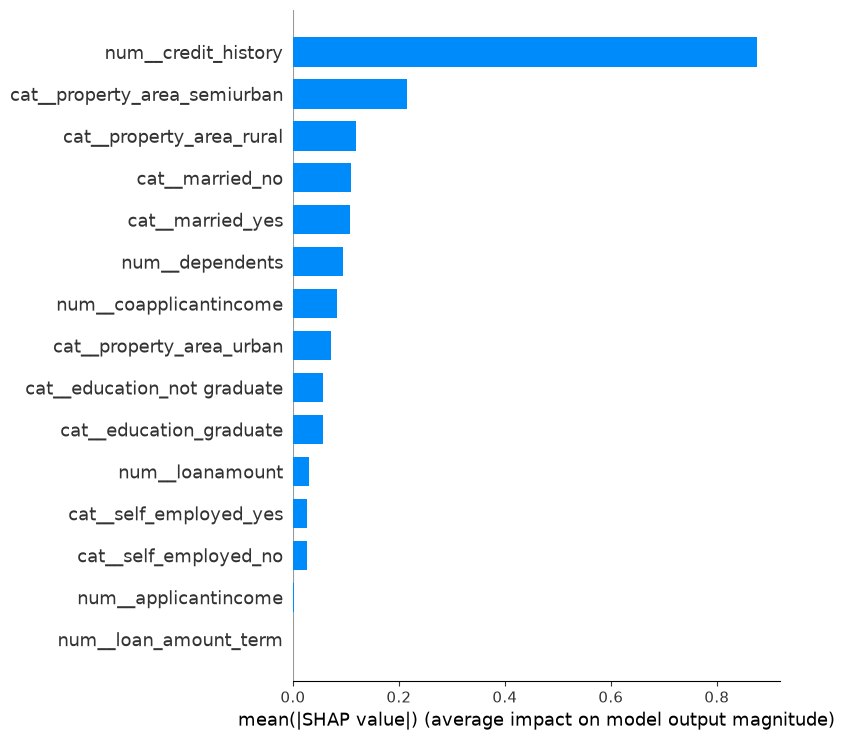

In [89]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

In [ ]:
applicant_index = 0

print("Actual loan status:",
      y_test.iloc[applicant_index])

print("Predicted loan status:",
      final_predictions[applicant_index])

print("Predicted probability:",
      final_probabilities[applicant_index])succ

Actual loan status: 0
Predicted loan status: 0
Predicted probability: 0.05831363354220487


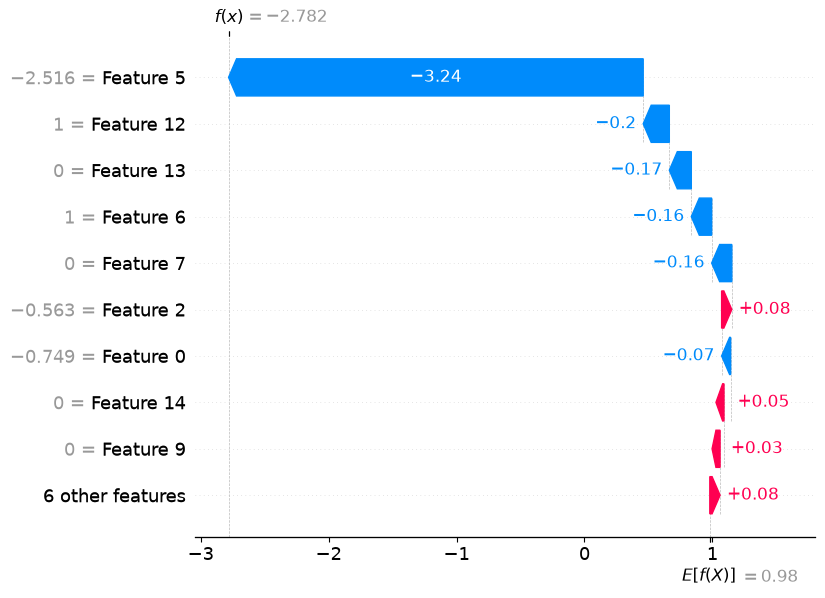

In [91]:
shap.plots.waterfall(
    shap_values[applicant_index],
    max_display=10
)

In [92]:
id="2yq7ka"


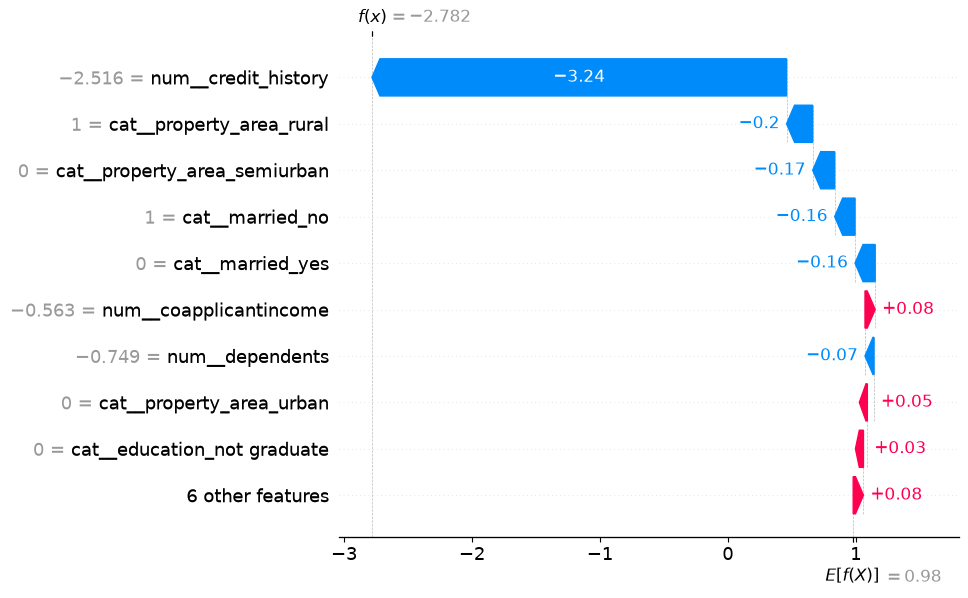

In [93]:
# Create a SHAP explanation for the first test applicant
applicant_explanation = shap.Explanation(
    values=shap_values[applicant_index].values,
    base_values=shap_values[applicant_index].base_values,
    data=X_test_transformed[applicant_index],
    feature_names=feature_names
)

shap.plots.waterfall(
    applicant_explanation,
    max_display=10
)

In [94]:
print("Actual status:",
      "Approved" if y_test.iloc[applicant_index] == 1 else "Not Approved")

print(
    "Predicted status:",
    "Approved" if final_predictions[applicant_index] == 1 else "Not Approved"
)

print(
    f"Model probability of approval: "
    f"{final_probabilities[applicant_index] * 100:.2f}%"
)

Actual status: Not Approved
Predicted status: Not Approved
Model probability of approval: 5.83%


In [95]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_model,
    "../models/loan_eligibility_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [96]:
model_config = {
    "features": features,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "target": target
}

joblib.dump(
    model_config,
    "../models/model_config.pkl"
)

print("Model configuration saved successfully!")

Model configuration saved successfully!


In [97]:
loaded_model = joblib.load(
    "../models/loan_eligibility_model.pkl"
)

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [98]:
test_predictions = loaded_model.predict(X_test)

test_probabilities = loaded_model.predict_proba(X_test)[:, 1]

print("Loaded model accuracy:",
      accuracy_score(y_test, test_predictions))

print("Loaded model ROC-AUC:",
      roc_auc_score(y_test, test_probabilities))

Loaded model accuracy: 0.8617886178861789
Loaded model ROC-AUC: 0.8554179566563468


In [99]:
# Save SHAP/XAI artifacts for the Streamlit application

xai_artifacts = {
    "background_data": X_train_transformed,
    "feature_names": feature_names
}

joblib.dump(
    xai_artifacts,
    "../models/xai_artifacts.pkl"
)

print("XAI artifacts saved successfully!")

XAI artifacts saved successfully!
